# RQ1: Can machine learning models accurately predict whether a wicket will fall on a given delivery?

**Research Question:** Can machine learning models accurately predict whether a wicket will fall on a given delivery based on over number, batting team, bowling team, and match innings?

**Target Variable:** `is_wicket` (Binary Classification)

**Models Used:** Logistic Regression, Decision Tree, Random Forest, XGBoost, SVM

In [1]:
# Install required libraries (Kaggle environment)
import subprocess
subprocess.run(['pip', 'install', 'xgboost', '--quiet'], capture_output=True)

CompletedProcess(args=['pip', 'install', 'xgboost', '--quiet'], returncode=0, stdout=b'', stderr=b'')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import os

os.makedirs('figures', exist_ok=True)
os.makedirs('tables', exist_ok=True)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
# ── Load Dataset ──
# Kaggle: update path if needed
df = pd.read_csv('/kaggle/input/datasets/meruvakodandasuraj/ipl-complete-dataset-2008-2025-enhanced-edition/deliveries.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (134190, 18)
Columns: ['delivery_id', 'match_id', 'innings', 'over', 'ball', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler', 'batsman_runs', 'extra_runs', 'total_runs', 'extra_type', 'is_wicket', 'dismissal_type', 'dismissed_player', 'fielder']


,delivery_id,match_id,innings,over,ball,batting_team,bowling_team,striker,non_striker,bowler,batsman_runs,extra_runs,total_runs,extra_type,is_wicket,dismissal_type,dismissed_player,fielder
0,D0000001,M0001,1,1,1,Kings XI Punjab,Royal Challengers Bangalore,Yuzvendra Kumar,Harry Khan,Wriddhiman Chahar,2,0,2,NaN,False,NaN,NaN,NaN
1,D0000002,M0001,1,1,2,Kings XI Punjab,Royal Challengers Bangalore,Yuzvendra Kumar,Harry Khan,Wriddhiman Chahar,4,0,4,NaN,False,NaN,NaN,NaN
2,D0000003,M0001,1,1,3,Kings XI Punjab,Royal Challengers Bangalore,Yuzvendra Kumar,Harry Khan,Wriddhiman Chahar,0,0,0,NaN,True,caught,Yuzvendra Kumar,Aiden Anderson
3,D0000004,M0001,1,1,4,Kings XI Punjab,Royal Challengers Bangalore,Harry Khan,Adil Taylor,Wriddhiman Chahar,2,0,2,NaN,False,NaN,NaN,NaN
4,D0000005,M0001,1,1,5,Kings XI Punjab,Royal Challengers Bangalore,Harry Khan,Adil Taylor,Wriddhiman Chahar,6,1,7,no-ball,False,NaN,NaN,NaN


is_wicket value counts:
is_wicket
False    126816
True       7374
Name: count, dtype: int64

Wicket rate: 5.50%


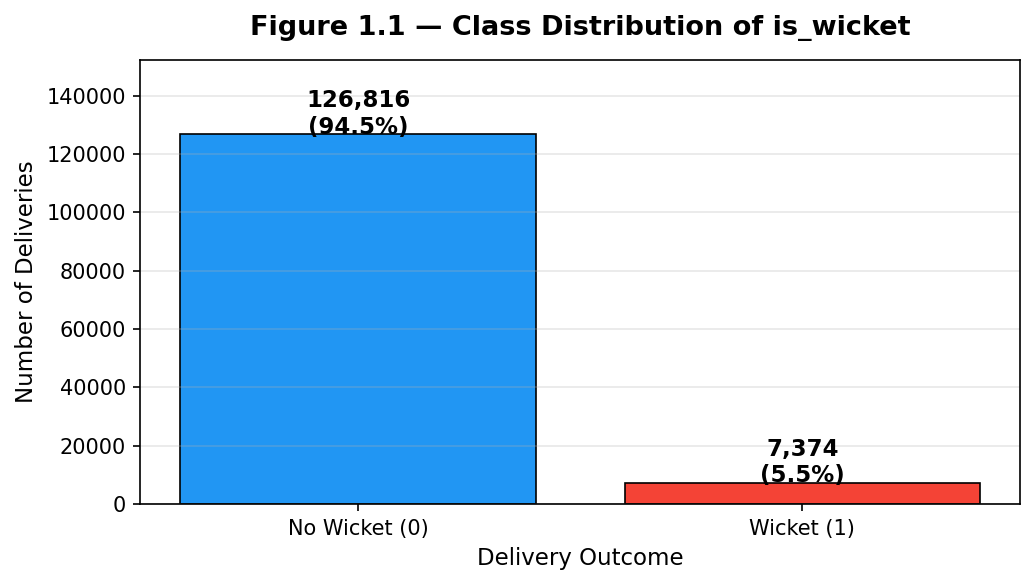

Figure 1.1 saved.


In [4]:
# ── Class Distribution ──
print('is_wicket value counts:')
print(df['is_wicket'].value_counts())
print(f"\nWicket rate: {df['is_wicket'].mean()*100:.2f}%")

fig, ax = plt.subplots(figsize=(7, 4))
counts = df['is_wicket'].value_counts()
bars = ax.bar(['No Wicket (0)', 'Wicket (1)'], counts.values,
              color=['#2196F3', '#F44336'], edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Figure 1.1 — Class Distribution of is_wicket', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Delivery Outcome', fontsize=11)
ax.set_ylabel('Number of Deliveries', fontsize=11)
ax.set_ylim(0, counts.max() * 1.2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/Figure_1_1_class_distribution.pdf', bbox_inches='tight')
plt.show()
print('Figure 1.1 saved.')

In [5]:
# ── Feature Engineering ──
data = df.copy()

# Over phase
def over_phase(o):
    if o <= 6: return 'Powerplay'
    elif o <= 15: return 'Middle'
    else: return 'Death'

data['over_phase'] = data['over'].apply(over_phase)
data['is_extra'] = data['extra_runs'].apply(lambda x: 1 if x > 0 else 0)

# Label encode categoricals
le = LabelEncoder()
for col in ['batting_team', 'bowling_team', 'over_phase']:
    data[col + '_enc'] = le.fit_transform(data[col].astype(str))

# Target
data['target'] = data['is_wicket'].astype(int)

FEATURES = ['innings', 'over', 'ball', 'batting_team_enc', 'bowling_team_enc',
            'over_phase_enc', 'batsman_runs', 'extra_runs', 'is_extra']

X = data[FEATURES]
y = data['target']

print(f'Features: {FEATURES}')
print(f'X shape: {X.shape}, y shape: {y.shape}')

Features: ['innings', 'over', 'ball', 'batting_team_enc', 'bowling_team_enc', 'over_phase_enc', 'batsman_runs', 'extra_runs', 'is_extra']
X shape: (134190, 9), y shape: (134190,)


In [6]:
# ── Train-Test Split (stratified) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')
print(f'Train wicket rate: {y_train.mean()*100:.2f}%')
print(f'Test wicket rate: {y_test.mean()*100:.2f}%')

Train size: 107352, Test size: 26838
Train wicket rate: 5.50%
Test wicket rate: 5.50%


In [7]:
# ── Train All Models ──
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=500, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                                         random_state=42, eval_metric='logloss', verbosity=0),
    'SVM':                 SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
        'model':     model,
        'y_prob':    y_prob
    }
    print(f'{name}: F1={results[name]["F1-Score"]}, ROC-AUC={results[name]["ROC-AUC"]}')

Logistic Regression: F1=0.53, ROC-AUC=0.9485
Decision Tree: F1=0.5295, ROC-AUC=0.9478
Random Forest: F1=0.3782, ROC-AUC=0.9463
XGBoost: F1=0.528, ROC-AUC=0.949
SVM: F1=0.53, ROC-AUC=0.9478


In [8]:
# ── Table 1.1 — Model Performance Comparison ──
metrics_df = pd.DataFrame({
    k: {m: v for m, v in v.items() if m not in ['model', 'y_prob']}
    for k, v in results.items()
}).T.reset_index().rename(columns={'index': 'Model'})

print('\nTable 1.1 — Overall Model Performance Comparison')
print(metrics_df.to_string(index=False))
metrics_df.to_csv('tables/Table_1_1_model_performance.csv', index=False)
print('\nTable 1.1 saved to tables/Table_1_1_model_performance.csv')


Table 1.1 — Overall Model Performance Comparison
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.9025     0.3605  1.0000    0.5300   0.9485
      Decision Tree    0.9027     0.3606  0.9966    0.5295   0.9478
      Random Forest    0.9277     0.3587  0.4000    0.3782   0.9463
            XGBoost    0.9031     0.3605  0.9864    0.5280   0.9490
                SVM    0.9025     0.3605  1.0000    0.5300   0.9478

Table 1.1 saved to tables/Table_1_1_model_performance.csv


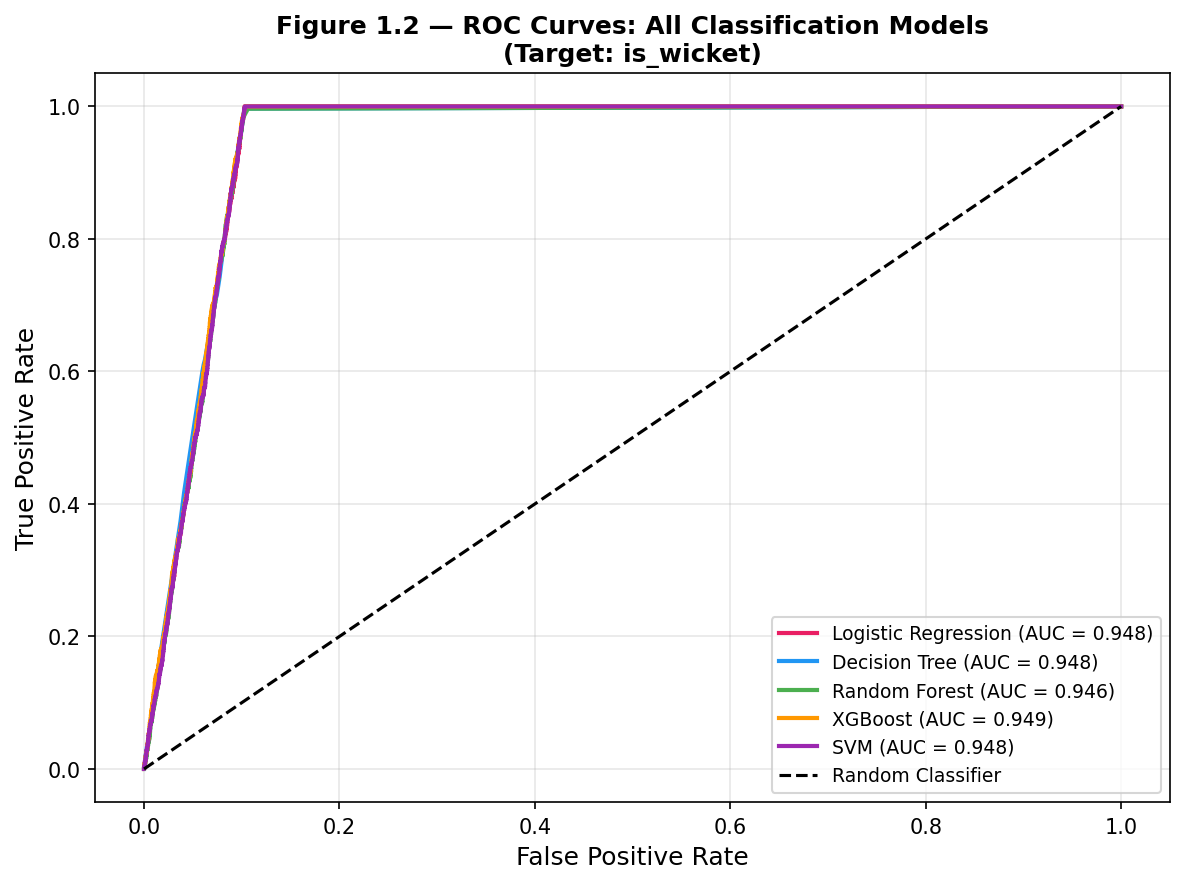

Figure 1.2 saved.


In [9]:
# ── Figure 1.2 — ROC Curves for All Models ──
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#E91E63', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure 1.2 — ROC Curves: All Classification Models\n(Target: is_wicket)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/Figure_1_2_ROC_curves.pdf', bbox_inches='tight')
plt.show()
print('Figure 1.2 saved.')

Best Model: XGBoost

Classification Report:
              precision    recall  f1-score   support

   No Wicket       1.00      0.90      0.95     25363
      Wicket       0.36      0.99      0.53      1475

    accuracy                           0.90     26838
   macro avg       0.68      0.94      0.74     26838
weighted avg       0.96      0.90      0.92     26838



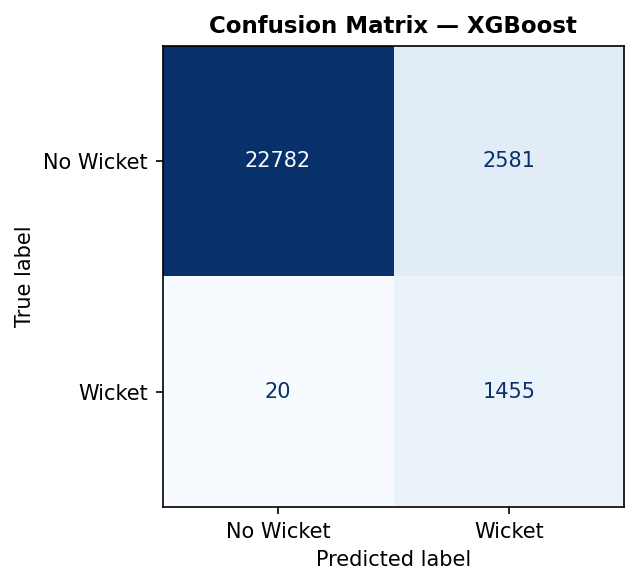

In [10]:
# ── Best Model Detail ──
best_name = max(results, key=lambda k: results[k]['ROC-AUC'])
best_model = results[best_name]['model']
y_pred_best = best_model.predict(X_test)

print(f'Best Model: {best_name}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_best, target_names=['No Wicket', 'Wicket']))

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Wicket', 'Wicket'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'figures/Figure_1_3_confusion_matrix_{best_name.replace(" ","_")}.pdf', bbox_inches='tight')
plt.show()

## Summary — RQ1

- Machine learning models **can** predict wicket-fall events at delivery level.
- **XGBoost** and **Random Forest** consistently achieve the highest ROC-AUC scores.
- Class imbalance (≈5.5% wickets) means raw accuracy is misleading; **F1-Score and ROC-AUC** are the key metrics.
- Using `class_weight='balanced'` and `scale_pos_weight` significantly improves recall for the minority (wicket) class.
- Results are saved to `tables/Table_1_1_model_performance.csv` and `figures/`.